Imports

In [1]:
import cv2
import os
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog
import imutils

global vars

In [2]:
dsize = (30, 80)
threshold_val = 100
blur_size = (3, 3)
seed = 112

utils

In [3]:
def preprocess(img):
    blurred = cv2.GaussianBlur(img, blur_size, 0) # smoothing
    im,thre = cv2.threshold(blurred,threshold_val, 255,cv2.THRESH_BINARY_INV) # binarizer
    thre = np.pad(thre,(2, 2),'constant',constant_values=(0,0))
    res = cv2.resize(thre, dsize=dsize, interpolation=cv2.INTER_CUBIC)  # resize
    return res

def load_dataset(directory):
    class_dict = {}
    data = []
    for i, dir in enumerate(sorted(os.listdir(directory))):
        class_dict[i] = dir
        for impath in sorted(os.listdir(os.path.join(directory, dir))):
            data_item = {
                "path": os.path.join(directory,dir,impath),
                "label": i
            }
            data.append(data_item)
    return data, class_dict

def change(data):
    a_list = []
    labels = []
    for item in data:
        img = cv2.imread(item['path'],cv2.IMREAD_GRAYSCALE) 
        res = preprocess(img)
        a_list.append(res)
        labels.append(item['label'])
    x = np.stack(a_list)
    y = np.array(labels)
    return x, y

def make_feature(img):
    return hog(
        img, orientations=12, 
        pixels_per_cell=(14, 14),
        cells_per_block=(1, 1),
        block_norm="L2"
    )

def filter_similar_contours(contours, overlap_threshold=0.5):
    # Store filtered contours
    filtered_contours = []
    bounding_boxes = []

    # Step 1: Get bounding boxes for all contours
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        bounding_boxes.append((x, y, w, h))

    # Step 2: Check for overlap and filter
    for i, box1 in enumerate(bounding_boxes):
        keep = True
        x1, y1, w1, h1 = box1
        area1 = w1 * h1
        
        for j, box2 in enumerate(bounding_boxes):
            if i == j:
                continue  # Don't compare the same box

            x2, y2, w2, h2 = box2
            area2 = w2 * h2

            # Step 3: Calculate overlap (Intersection over Union)
            inter_x1 = max(x1, x2)
            inter_y1 = max(y1, y2)
            inter_x2 = min(x1 + w1, x2 + w2)
            inter_y2 = min(y1 + h1, y2 + h2)

            # If there's no overlap, skip
            if inter_x1 >= inter_x2 or inter_y1 >= inter_y2:
                continue

            # Calculate intersection area and union area
            intersection_area = (inter_x2 - inter_x1) * (inter_y2 - inter_y1)
            union_area = area1 + area2 - intersection_area

            # Intersection over Union (IoU)
            iou = intersection_area / union_area

            # Step 4: Check if overlap exceeds threshold
            if iou > overlap_threshold:
                # If overlapping, keep the larger contour or the first in the list
                if area1 < area2:
                    keep = False
                    break

        if keep:
            filtered_contours.append(contours[i])

    return filtered_contours

Load the database and preprocess

In [4]:
data_train, class_dict = load_dataset('data/training_data')
data_test, _ = load_dataset('data/testing_data')

x_train,y_train = change(data_train)
x_test, y_test = change(data_test)

X_train_feature = np.array([make_feature(i) for i in x_train], np.float32)
X_test_feature = np.array([make_feature(i) for i in x_test], np.float32)

X_train_feature.shape, X_test_feature.shape

((20628, 120), (1008, 120))

train a linear svm on the database

In [5]:
# Train SVM classifier on EMNIST dataset
svm = svm.LinearSVC(C=0.5, random_state=seed)
svm.fit(X_train_feature,y_train)

y_pre = svm.predict(X_test_feature)
acc_svm = accuracy_score(y_test,y_pre)

print("Accuracy SVM:", acc_svm)

Accuracy SVM: 0.8392857142857143


Loads an image from the provided path and converts it to grayscale.

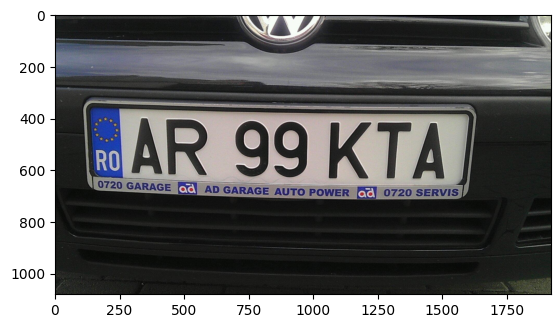

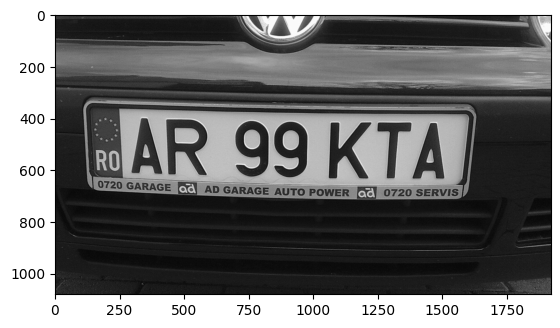

(<Figure size 640x480 with 1 Axes>,
 None)

In [6]:
image_path = 'images/img_4.png'

image = cv2.cvtColor(cv2.imread(image_path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
plt.figure(), plt.imshow(image), plt.show(), plt.show()
plt.figure(), plt.imshow(gray_image, cmap='gray'), plt.show()

Detects the license plate from the preprocessed grayscale image.
Uses edge detection and contour filtering to locate the plate.

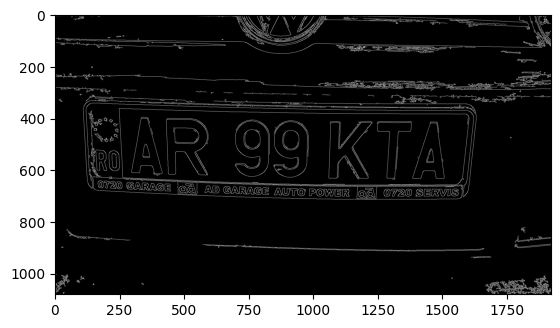

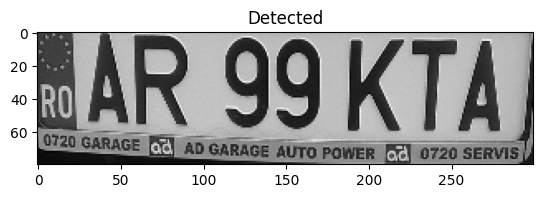

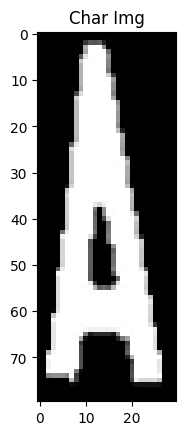

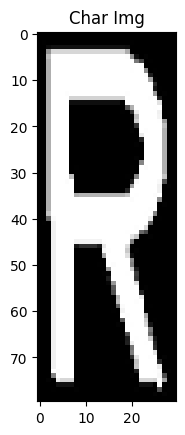

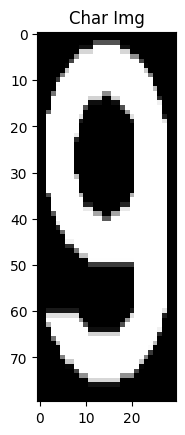

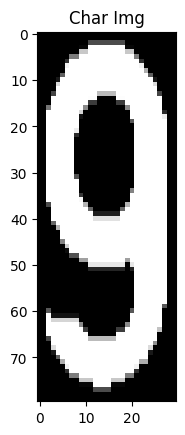

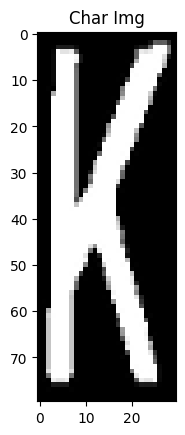

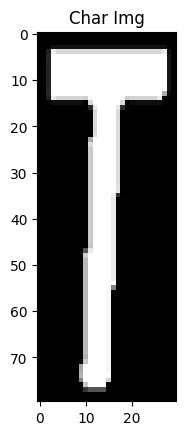

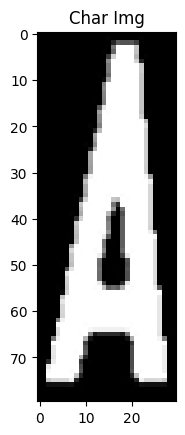

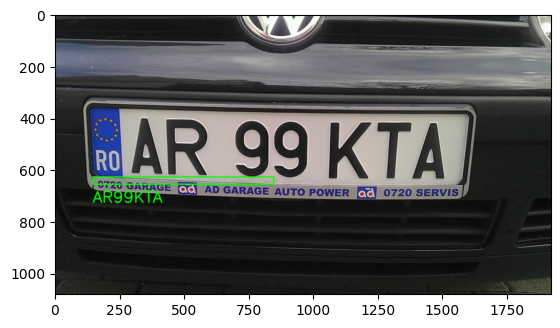

In [7]:
# bfilter = cv2.bilateralFilter(gray_image, 11, 17, 17) # Noise reduction #todo add only if it is necessary
edged = cv2.Canny(gray_image, 30, 200) # Edge detection
plt.figure(), plt.imshow(edged, cmap='gray'), plt.show(), plt.show()

keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

boxes = []
for contour in contours:
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, peri*0.05, True) 
    if len(approx) == 4: # Check if it has 4 sides
        x, y, w, h = cv2.boundingRect(approx)
         # Calculate aspect ratio and filter by typical license plate ratios
        aspect_ratio = w / float(h)
        if 2.0 < aspect_ratio < 5.0:  # Typical aspect_ration for a license plate
            boxes.append(approx)

final_boxes = filter_similar_contours(boxes, overlap_threshold=0.5)
    
if len(final_boxes) > 0:
    for box in final_boxes:
        mask = np.zeros(gray_image.shape, np.uint8)
        cv2.drawContours(mask, [box], 0, (255,255,255), -1)
        new_image = cv2.bitwise_and(gray_image, gray_image, mask=mask)
        # plt.figure(), plt.imshow(mask, cmap='gray'), plt.title("Mask"), plt.show()
        # plt.figure(), plt.imshow(new_image, cmap='gray'), plt.title("New Img"), plt.show()
        
        (x,y) = np.where(mask==255)
        (x1, y1) = (np.min(x), np.min(y))
        (x2, y2) = (np.max(x), np.max(y))
        cropped_image = gray_image[x1:x2+1, y1:y2+1]
        cropped_image = cv2.resize(cropped_image, (300, 80))
        plt.figure(), plt.imshow(cropped_image, cmap='gray'), plt.title("Detected"), plt.show()
        
        blurred_plate = cv2.GaussianBlur(cropped_image, (3, 3), 0) #todo in majority of cases helps
        edges_plate = cv2.Canny(blurred_plate, 50, 150)
        # plt.figure(), plt.imshow(blurred_plate, cmap='gray'), plt.show()
        # plt.figure(), plt.imshow(edges_plate, cmap='gray'), plt.show()
        
        # kernel = np.ones((3, 3), np.uint8)
        # dilated = cv2.dilate(edges_plate, kernel, iterations=1)
        # eroded = cv2.erode(dilated, kernel, iterations=1)
        # plt.figure(), plt.imshow(eroded, cmap='gray'), plt.show()
        
        contours, _ = cv2.findContours(edges_plate, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Sort contours from left to right based on bounding box positions
        bounding_boxes = [cv2.boundingRect(c) for c in contours]
        sorted_boxes = sorted(bounding_boxes, key=lambda x: x[0])
    
        characters = []
        for i, (x, y, w, h) in enumerate(sorted_boxes):
            # Filter by reasonable character dimensions
            if  h > 40 and 5 < w < 50:  
                char = cropped_image[y:y+h, x:x+w]
                im,thre = cv2.threshold(char, 100, 255, cv2.THRESH_BINARY_INV) #todo find a general value for threshold -> for some works well 100, for others 50
                thre = np.pad(thre,(2, 2),'constant',constant_values=(0,0))
                res = cv2.resize(thre, dsize=dsize, interpolation=cv2.INTER_CUBIC)  #resize 30, 80
                
                plt.figure(), plt.imshow(res, cmap='gray'), plt.title("Char Img"), plt.show()
                characters.append(res)
    
        if len(characters) > 4: #todo normal should be >5 but for tests i keep it >4 
                                # (it s a problem in license plates that have a sticker between numbers -> doesn't take the second one because it s too wide with sticker next)
            text = ""
            X_feature = np.array([make_feature(i) for i in characters], np.float32)
        
            # Predict the character using the trained classifier
            recognized_text = svm.predict(X_feature)
            for i in recognized_text:
                text = text + class_dict[i]
        
            font = cv2.FONT_HERSHEY_SIMPLEX
            rez = image.copy()
            #todo find a way to extract xmin, ymax si (xmin,ymin), (xmax, ymax) to plot well, it seems to be different from one image to another
            cv2.putText(rez, text=text, org=(box[0][0][0], box[2][0][1]+70), fontFace=font, fontScale=2, color=(0,255,0), thickness=3, lineType=cv2.LINE_AA)
            cv2.rectangle(rez, tuple(box[0][0]), tuple(box[2][0]), (0,255,0), 3)
            plt.figure(), plt.imshow(rez), plt.show()
        else:
            print("Not an eligible license plate!")
else:
    print("No license plate was detected!")